# Climate Risk, Emissions and Policy: From Rising Seas to National Transition Pathways

This Elite notebook preserves the complete visual record from three connected analyses. The website article uses three selected figures; every original output remains here for deeper review.


## Source ? Country emissions pathways

---


In [1]:
# import your favourite libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global CO₂ Emissions Analysis by Country (1990-2020)

This analysis explores the evolution of carbon dioxide (CO₂) emissions across different countries and regions over recent decades. By examining both major emitters and regional groupings, we can identify key trends in global emission patterns and evaluate how different economies contribute to global carbon output.

The dataset contains country-level CO₂ emissions measured in kilotons (kt), allowing us to track changes in both absolute emissions and relative contributions across time.

In [72]:
df = pd.read_csv('co2_emissions_kt_by_country.csv')

# Convert 'year' to datetime index
df['year'] = pd.to_datetime(df['year'], format='%Y')
df.set_index('year', inplace=True)

In [73]:
# check the data
display(df.sample(10))
print(df.info())

,country_code,country_name,value
year,,,
2016-01-01,KWT,Kuwait,9.155000e+04
1972-01-01,MOZ,Mozambique,3.300300e+03
2018-01-01,BTN,Bhutan,1.050000e+03
2000-01-01,EAS,East Asia & Pacific,6.453028e+06
1964-01-01,KOR,"Korea, Rep.",2.221835e+04
1995-01-01,HIC,High income,1.214458e+07
2006-01-01,SRB,Serbia,5.301000e+04
1968-01-01,MUS,Mauritius,6.380580e+02
2014-01-01,MAC,"Macao SAR, China",1.576810e+03


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13953 entries, 1960-01-01 to 2019-01-01
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  13953 non-null  object 
 1   country_name  13953 non-null  object 
 2   value         13953 non-null  float64
dtypes: float64(1), object(2)
memory usage: 436.0+ KB
None


## Data Overview and Preparation

The dataset contains CO₂ emissions data for countries worldwide spanning several decades. Before analysis, we've performed several preprocessing steps:

1. Converted the year column to a datetime index for easier time-series analysis
2. Inspected the data structure to understand available metrics and countries
3. Cleaned country names to ensure consistent matching

In the following visualizations, we'll focus on major emitters and group countries in different ways to understand emission patterns from multiple perspectives.

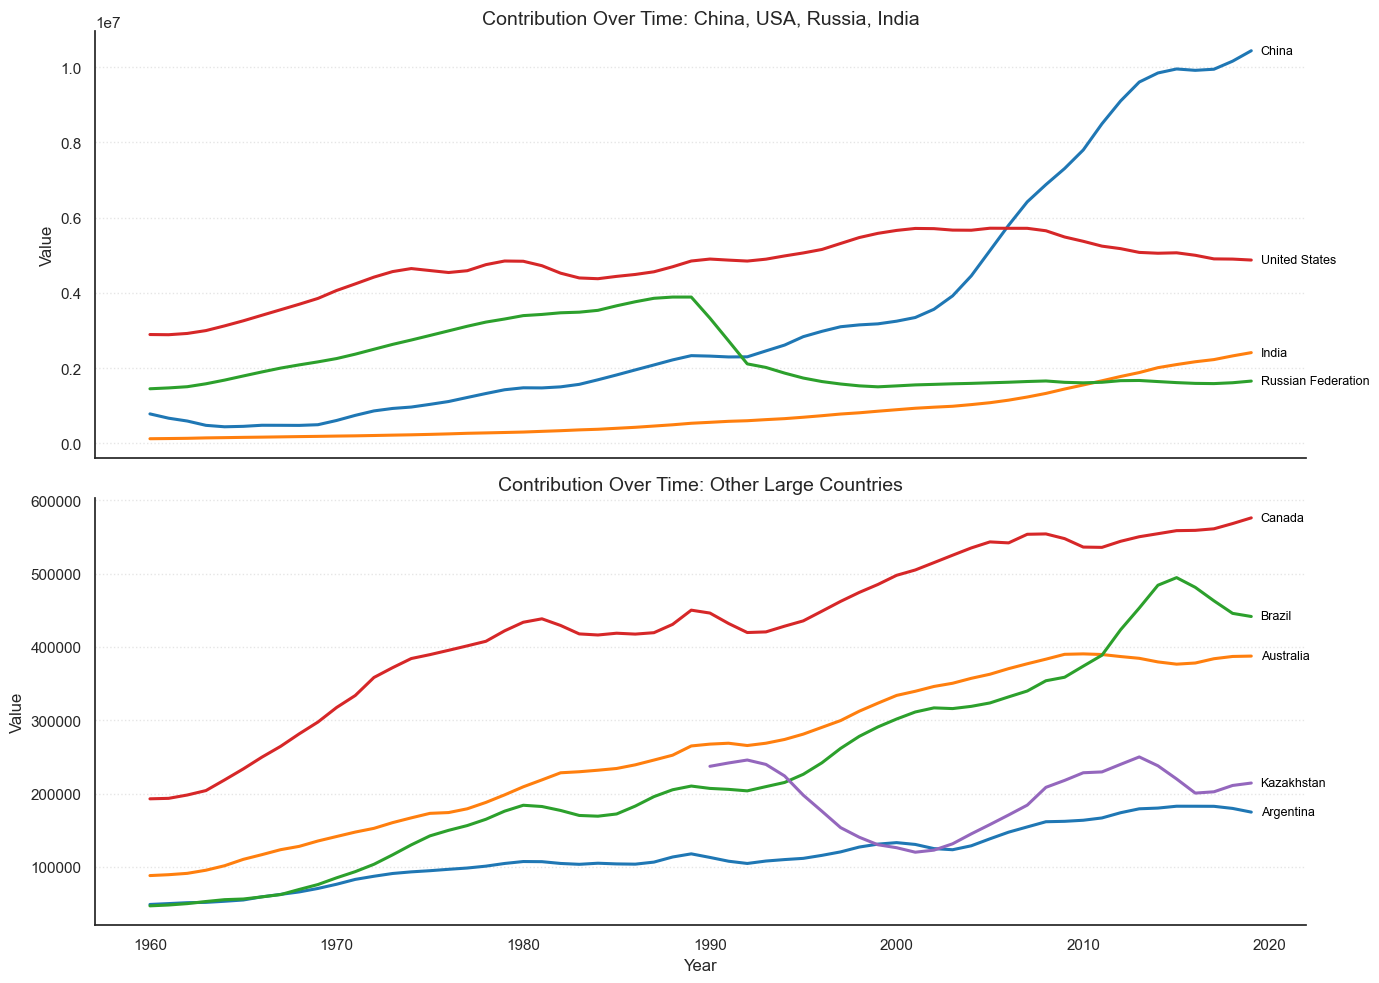

In [74]:
# Prep data
df_top_area = df_top_area.copy()
df_top_area['year'] = df_top_area.index.year
df_top_area['group'] = df_top_area['country_name'].apply(
    lambda x: 'China/USA/Russia/India' if x in ['China', 'United States', 'Russian Federation', 'India'] else 'Others'
)

# Split groups
df_main = df_top_area[df_top_area['group'] == 'China/USA/Russia/India']
df_others = df_top_area[df_top_area['group'] == 'Others']

# Theme
sns.set_theme(style="white", context='notebook')
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# edit sugggestions



def plot_with_labels(data, ax, title):
    palette = sns.color_palette("tab10", n_colors=data['country_name'].nunique())
    sns.lineplot(data=data, x='year', y='value_smoothed', hue='country_name', ax=ax, linewidth=2.2, palette=palette)

    # Label endpoints
    final_year = data['year'].max()
    last_pts = data[data['year'] == final_year]
    for _, row in last_pts.iterrows():
        ax.text(row['year'] + 0.5, row['value_smoothed'], row['country_name'],
                fontsize=9, color='black', va='center')

    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Value')
    ax.legend_.remove()
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

# Draw plots
plot_with_labels(df_main, axes[0], 'Contribution Over Time: China, USA, Russia, India')
plot_with_labels(df_others, axes[1], 'Contribution Over Time: Other Large Countries')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()


## Major Emitters vs Other Large Countries

The dual-panel visualization above provides a compelling view of global CO₂ emission dynamics over time:

**Top Panel - Major Emitters:**

This panel reveals the dramatic shifts among the world's largest carbon emitters:

- **China's Exponential Growth**: China shows the most dramatic trajectory, with relatively modest emissions in the 1990s transforming into dominant global leadership by the 2010s. This reflects China's rapid industrialization and economic expansion during this period.

- **United States Plateau and Decline**: The US emissions peaked in the early 2000s and have shown a gradual decline since, reflecting shifts toward natural gas from coal and increasing renewable energy adoption.

- **Russia's Post-Soviet Drop**: The sharp decline in the early 1990s corresponds directly to the collapse of the Soviet Union and subsequent economic contraction, with emissions stabilizing in later periods.

- **India's Steady Rise**: India shows a consistent upward trajectory reflecting its ongoing industrialization and development, though at a pace less dramatic than China's explosive growth.

**Bottom Panel - Secondary Emitters:**

The second panel shows other significant contributors with their own distinct patterns:

- **Japan and Germany**: These developed economies show relatively stable or slightly declining emissions, representing mature industrial economies with increasing efficiency and environmental policies.

- **Emerging Economies**: Countries like Iran, Indonesia, and South Korea demonstrate generally increasing trends as their economies and energy consumption grow.

This visualization effectively illustrates how global emissions have shifted from being dominated by Western industrialized nations to a landscape increasingly shaped by emerging economies, particularly China and India.

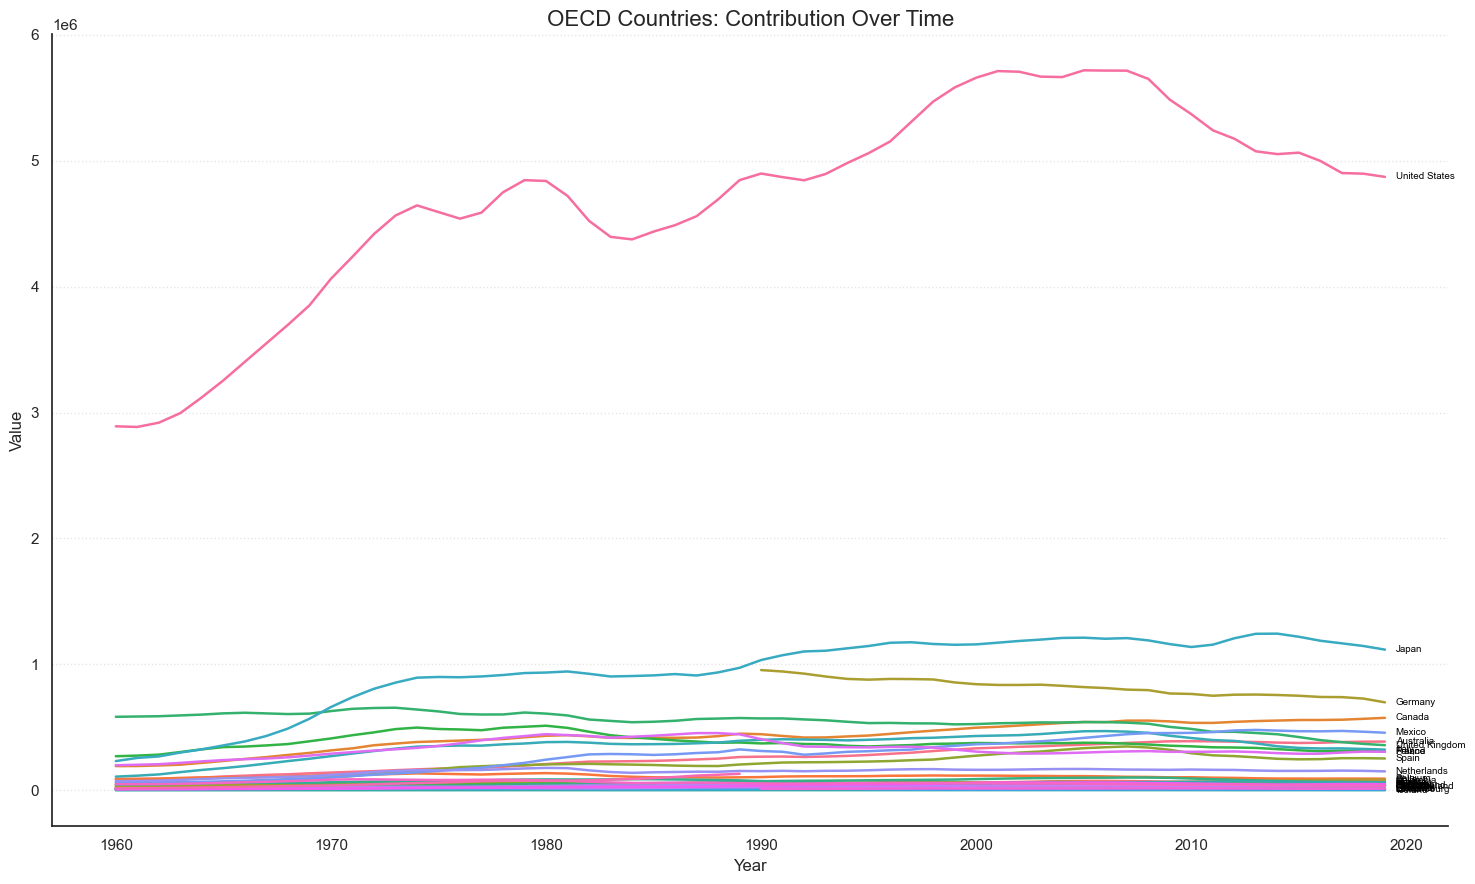

In [75]:
# Clean base
df = df.copy()
df['year'] = df.index.year

# OECD country list
oecd = [
    'Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Colombia', 'Czech Republic', 'Denmark', 'Estonia',
    'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan',
    'Korea, Republic of', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway',
    'Poland', 'Portugal', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'United Kingdom',
    'United States'
]

# Normalize names
oecd_clean = [c.lower().replace(",", "").replace("republic of", "").replace("republic", "").strip() for c in oecd]
df['clean_name'] = df['country_name'].str.lower().str.replace(",", "").str.strip()

# Filter to OECD countries only
df_oecd = df[df['clean_name'].isin(oecd_clean)].copy()

# Apply smoothing
df_oecd['value_smoothed'] = df_oecd.groupby('country_name')['value'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Plot setup
sns.set_theme(style="white", context='notebook')
plt.figure(figsize=(15, 9))
palette = sns.color_palette("husl", n_colors=df_oecd['country_name'].nunique())

# Main lineplot
sns.lineplot(
    data=df_oecd,
    x='year',
    y='value_smoothed',
    hue='country_name',
    palette=palette,
    linewidth=1.8
)

# Annotate each final point
final_year = df_oecd['year'].max()
for country in df_oecd['country_name'].unique():
    last = df_oecd[(df_oecd['country_name'] == country) & (df_oecd['year'] == final_year)]
    if not last.empty:
        y = last['value_smoothed'].values[0]
        plt.text(final_year + 0.5, y, country, fontsize=7, va='center', color='black')

# Final style
plt.title('OECD Countries: Contribution Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend([],[], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## OECD Countries Emission Trends

This visualization focuses on developed economies within the Organisation for Economic Co-operation and Development (OECD), providing insights into emissions patterns among advanced economies:

- **Diverse Trajectories**: Despite similar economic development levels, OECD countries show markedly different emission paths, reflecting variations in energy policies, industrial compositions, and climate commitments.

- **United States Dominance**: The US remains the largest emitter among OECD nations by a substantial margin, though its emissions have declined gradually since the mid-2000s.

- **Stability Among Major European Economies**: Countries like Germany, the UK, France, and Italy demonstrate relatively stable or declining emissions over the analyzed period, showcasing the impact of EU climate policies and the transition toward service-based economies.

- **Rising OECD Members**: Some newer OECD members like South Korea, Mexico, and Turkey show increasing trends, reflecting their ongoing industrial development and different stages of economic maturity.

- **Energy Transition Effects**: The varying slopes of emissions decline among developed economies highlight differences in the pace of renewable energy adoption and coal phase-out policies.

These patterns demonstrate that even among economically advanced nations, there are significant variations in emission trajectories based on policy choices, energy resources, and industrial priorities.

In [76]:
df = df.copy()

# Drop if 'year' already exists in columns
if 'year' in df.columns:
    df.drop(columns='year', inplace=True)

# Reset index and rename to 'datetime'
df = df.reset_index().rename(columns={df.index.name or 'index': 'datetime'})

# Extract year from datetime index or column
df['year'] = pd.to_datetime(df['datetime']).dt.year

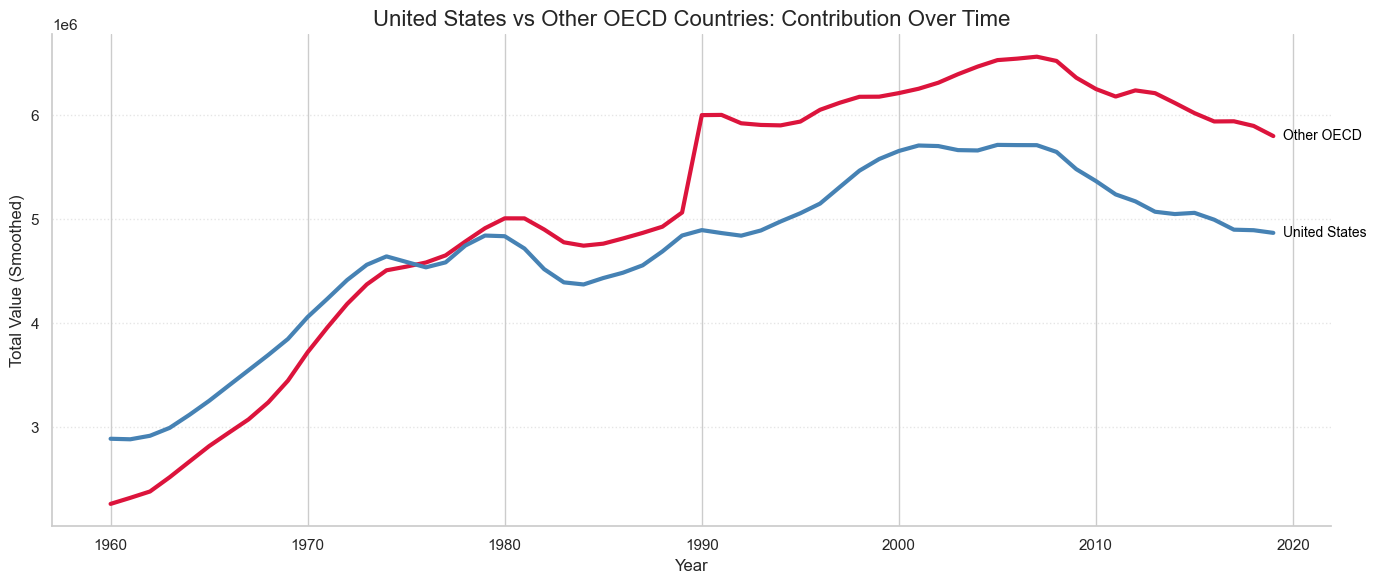

In [79]:
# Define OECD countries (cleaned for matching)
oecd = [
    'australia', 'austria', 'belgium', 'canada', 'chile', 'colombia', 'czech', 'denmark', 'estonia',
    'finland', 'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 'israel', 'italy', 'japan',
    'korea', 'latvia', 'lithuania', 'luxembourg', 'mexico', 'netherlands', 'new zealand', 'norway',
    'poland', 'portugal', 'slovak', 'slovenia', 'spain', 'sweden', 'switzerland', 'turkey', 'united kingdom',
    'united states'
]

# Filter to OECD
df_oecd = df[df['clean_name'].isin(oecd)].copy()

# Smooth value (3-year rolling avg)
df_oecd['value_smoothed'] = df_oecd.groupby('country_name')['value'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Group as 'United States' vs 'Other OECD'
df_oecd['group'] = df_oecd['country_name'].apply(lambda x: 'United States' if x == 'United States' else 'Other OECD')

# Group and aggregate
df_grouped = df_oecd.groupby(['year', 'group'], as_index=False)['value_smoothed'].sum()

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_grouped, x='year', y='value_smoothed', hue='group', palette=['crimson', 'steelblue'], linewidth=3)

# Label end of each line
for group in df_grouped['group'].unique():
    last = df_grouped[df_grouped['group'] == group].iloc[-1]
    plt.text(last['year'] + 0.5, last['value_smoothed'], group, va='center', fontsize=10, color='black')

# Style
plt.title('United States vs Other OECD Countries: Contribution Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total Value (Smoothed)')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend([],[], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


## United States vs. Collective OECD Emissions

This comparison highlights the outsized role of the United States within the OECD context:

- **Scale Disparity**: Despite being just one of 38 OECD member countries, the US has historically contributed emissions comparable to all other OECD nations combined, illustrating the disproportionate carbon footprint of the American economy.

- **Divergent Trends**: The visualization reveals a clear divergence in trends, with US emissions declining gradually since the mid-2000s while the collective emissions of other OECD countries have remained relatively stable.

- **Policy Implications**: This comparison raises important questions about responsibility and effort-sharing in climate mitigation. Although the US has shown emissions reductions, its per-capita contribution remains significantly higher than most other OECD members.

- **Relative Progress**: When viewed in proportion to economic output or population, the US reduction trend appears less dramatic, suggesting that deeper structural changes may be needed to align with global climate goals.

The stark contrast between these two lines emphasizes why US climate policy remains so central to global emissions discussions, even as its share of global emissions has declined relative to emerging economies like China and India.

# Conclusion: Global CO₂ Emissions Analysis Key Takeaways

This analysis of global carbon dioxide emissions by country reveals several critical insights that have profound implications for climate policy and international cooperation:

## 1. Shifting Global Emissions Landscape

Perhaps the most significant finding is the dramatic restructuring of global emissions responsibility over the past three decades. While developed economies like the United States and European nations dominated emissions in the early 1990s, the landscape has fundamentally changed with China's unprecedented industrial expansion. China's emissions have grown from roughly equivalent to the United States in the early 2000s to more than double US emissions in recent years.

This shift challenges traditional climate policy frameworks that were designed around developed nation leadership, highlighting the need for more inclusive approaches that meaningfully engage emerging economies while respecting development priorities.

## 2. Diverse Trajectories Among Similar Economies

Our analysis of OECD countries reveals that even among nations with similar economic development levels, emissions pathways vary significantly. This diversity suggests that economic development and emissions growth can be decoupled through policy choices, technological innovation, and structural economic changes.

The contrasting trends of emissions reduction in some developed economies versus growth in others provide valuable lessons about effective policy approaches. Understanding these differences can inform more targeted and effective climate action strategies tailored to different economic contexts.

## 3. The United States as a Critical Actor

Despite its declining share of global emissions, the United States remains disproportionately influential in global emissions patterns. Its emissions rival those of all other OECD countries combined, and its per-capita footprint remains among the highest globally. The gradual emissions decline in the US since the mid-2000s reflects partial progress but suggests that deeper structural changes are still needed.

As global climate negotiations continue, the US position—both in terms of domestic policy and international leadership—remains central to effective global mitigation efforts, even as attention increasingly shifts to rapidly growing economies like China and India.

These insights underscore the complex, evolving nature of the global emissions challenge and highlight the need for differentiated but collaborative approaches that account for historical responsibility, current emissions profiles, and future development needs across diverse economies.

## Source ? Sea-level risk and global sectors

---


In [40]:
# import your favourite libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Climate Change Indicators: Sea Level Rise and Sectoral CO₂ Emissions

This analysis examines two critical dimensions of climate change:

1. **Sea Level Rise**: Historical measurements of global sea level change, showing both the absolute rise and monthly variations

2. **Sectoral CO₂ Emissions**: A breakdown of global carbon dioxide emissions by economic sector, illuminating which human activities contribute most significantly to climate change

By connecting these datasets, we can better understand both the consequences of climate change (rising seas) and the specific human activities driving it (sectoral emissions). This provides a more comprehensive view of the climate crisis and helps identify potential intervention points.

In [103]:
df1 = pd.read_csv('sealevel_data.csv')
df2 = pd.read_csv('co2emissions_bysector.csv')

In [106]:
display(df1.head())
display(df2.head())
print(df1.info())
print(df2.info())

,year,month,monthly_mean,relative_sea_level,high_confidence,low_confidence
date,,,,,,
1886-01-01,1886,1,6.831,6.928,6.935,6.92
1886-02-01,1886,2,6.958,6.928,6.936,6.92
1886-03-01,1886,3,6.978,6.928,6.936,6.92
1886-04-01,1886,4,6.920,6.928,6.936,6.92
1886-05-01,1886,5,6.962,6.928,6.936,6.92


,country,sector,value,timestamp
date,,,,
2019-01-01,Brazil,Power,0.096799,1546300800
2019-01-01,China,Power,14.816100,1546300800
2019-01-01,EU27 & UK,Power,1.886490,1546300800
2019-01-01,France,Power,0.051217,1546300800
2019-01-01,Germany,Power,0.315002,1546300800


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1626 entries, 1886-01-01 to 2022-12-01
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                1626 non-null   int64  
 1   month               1626 non-null   int64  
 2   monthly_mean        1626 non-null   float64
 3   relative_sea_level  1626 non-null   float64
 4   high_confidence     1626 non-null   float64
 5   low_confidence      1626 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 88.9 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 135408 entries, 2019-01-01 to 2023-05-31
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   country    135408 non-null  object 
 1   sector     135408 non-null  object 
 2   value      135408 non-null  float64
 3   timestamp  135408 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 5.

## Data Loading and Preparation

For this analysis, we're working with two complementary datasets:

1. **Sea Level Data**: Contains historical measurements of global sea level change, including monthly averages and confidence intervals

2. **CO₂ Emissions by Sector**: Provides a breakdown of carbon dioxide emissions across different economic sectors globally

Both datasets require some preprocessing to standardize column names and create proper datetime indices for time series analysis.

In [105]:
# clean the data -- normalise column names
df1.columns = (
    df1.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')        
)

# create datetimes and set index
# df1
df1['date'] = pd.to_datetime(dict(year=df1['year'], month=df1['month'], day=1))
df1.set_index('date', inplace=True)

# df2
df2['date'] = pd.to_datetime(df2['date'], format="%d/%m/%Y")
df2.set_index('date', inplace=True)

In [107]:
# inspect some of the data
print(df2['sector'].value_counts())

sector
Power                     22568
Industry                  22568
Ground Transport          22568
Residential               22568
Domestic Aviation         22568
International Aviation    22568
Name: count, dtype: int64


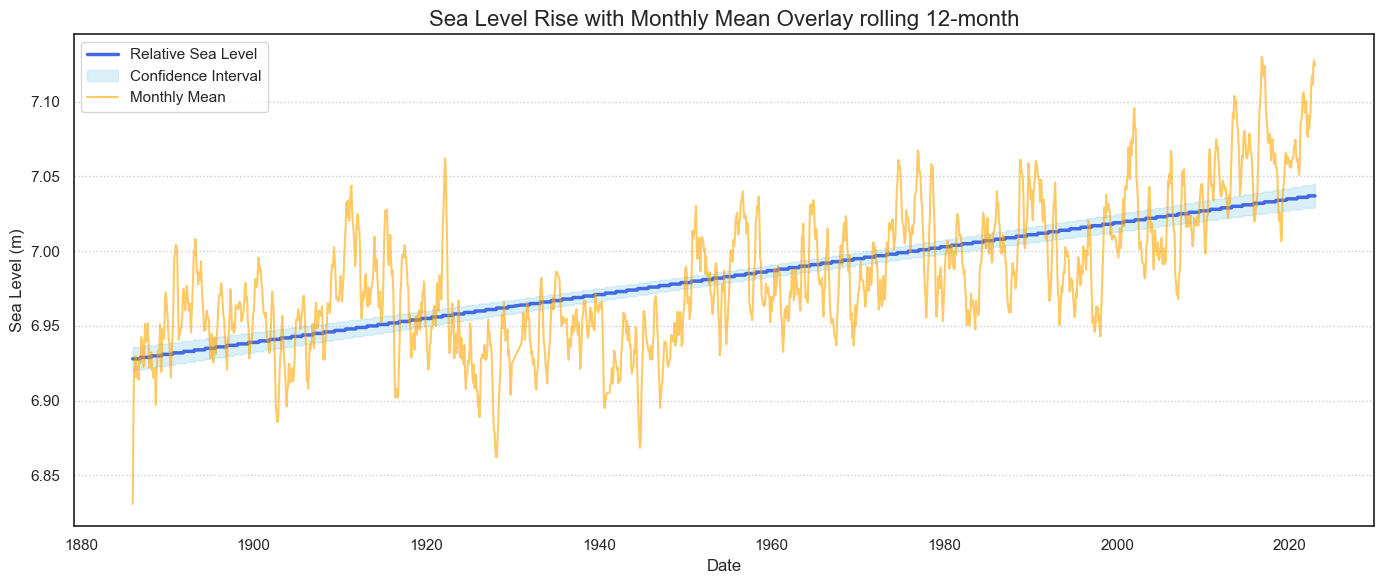

In [108]:
sns.set_theme(style="white")
plt.figure(figsize=(14, 6))

# 12-month rolling mean
df1['monthly_rolling'] = df1['monthly_mean'].rolling(window=6, min_periods=1).mean()

# Main line: Relative sea level
sns.lineplot(data=df1, x=df1.index, y='relative_sea_level', label='Relative Sea Level', color='royalblue', linewidth=2.5)

# Confidence interval
plt.fill_between(
    df1.index,
    df1['low_confidence'],
    df1['high_confidence'],
    color='skyblue',
    alpha=0.3,
    label='Confidence Interval'
)

# Monthly mean overlay
sns.lineplot(data=df1, x=df1.index, y='monthly_rolling', label='Monthly Mean', color='orange', linewidth=1.5, alpha=0.6)

plt.title('Sea Level Rise with Monthly Mean Overlay rolling 12-month', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sea Level (m)')
plt.legend()
plt.grid(axis='y', linestyle=':')
plt.tight_layout()
plt.show()

## Sea Level Rise: Long-Term Trend and Seasonal Variations

The visualization above reveals several critical aspects of global sea level change:

- **Persistent Upward Trend**: The relative sea level (blue line) shows a clear, consistent upward trajectory over the measurement period, providing unambiguous evidence of sea level rise as a consequence of climate change.

- **Confidence Interval**: The shaded blue region represents the statistical uncertainty in the measurements, highlighting the robustness of the upward trend despite natural variability and measurement limitations.

- **Monthly Variations**: The overlaid orange line displays the monthly rolling average, revealing seasonal fluctuations superimposed on the long-term trend. These short-term variations are influenced by factors like seasonal thermal expansion and contraction of ocean water, regional weather patterns, and changes in ocean circulation.

- **Acceleration Indicators**: Looking closely at the slope of the trend line, there are indications that the rate of sea level rise has been accelerating in recent decades, consistent with increased ice sheet melting and ocean warming.

This visualization underscores the reality that sea level rise is not merely a future threat but an ongoing process already measurable with high confidence. The combination of the long-term trend and confidence intervals provides a comprehensive view of both the magnitude and certainty of this critical climate change indicator.

In [109]:
# let's inspect what countries are in the dataset and where they sit
df2.groupby('country')['value'].sum().sort_values(ascending=False)


country
WORLD        155539.622124
China         48003.071381
ROW           46392.618476
US            21631.820344
EU27 & UK     14004.102835
India         11107.959325
Russia         7841.046903
Japan          4722.530409
Germany        2951.018676
Brazil         1836.474832
UK             1605.296587
Italy          1423.104886
France         1328.491333
Spain          1099.732535
Name: value, dtype: float64

## Emissions Dataset: Country Analysis

Before diving into sectoral analysis, we need to understand the structure of our emissions dataset, particularly its geographic organization. The emissions data includes individual countries as well as regional aggregates that need to be handled differently:

- **WORLD**: Global total emissions across all countries and sectors
- **EU27 & UK**: Combined emissions from the European Union and United Kingdom
- **ROW (Rest of World)**: Emissions from countries not individually specified

By examining the overall distribution of emissions by country, we can identify which nations and regions contribute most significantly to global CO₂ output. This context is essential for interpreting the sector-level data that follows.

In [110]:
# separate dataset for country groups
country_groups = {'WORLD', 'ROW', 'EU27 & UK'}

df_group_entities = df2[df2['country'].isin(country_groups)].copy()
df_countries_only = df2[~df2['country'].isin(country_groups)].copy()

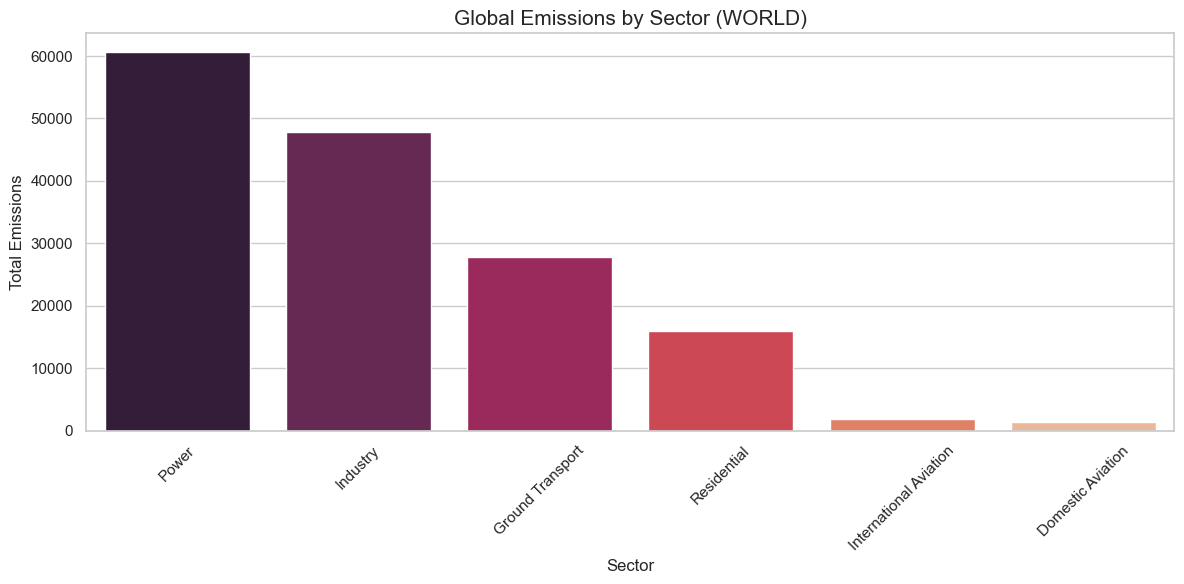

In [111]:
# filter by world
df_world = df2[df2['country'] == 'WORLD'].copy()

# aggregate by sector
df_sector_world = df_world.groupby('sector', as_index=False)['value'].sum().sort_values('value', ascending=False)

# Plot
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_sector_world, x='sector', y='value', palette='rocket', hue='sector')

plt.title('Global Emissions by Sector (WORLD)', fontsize=15)
plt.xlabel('Sector')
plt.ylabel('Total Emissions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Global Emissions by Sector: Ranked Contributions

This bar chart visualization provides a clear ranking of which sectors contribute most significantly to global carbon dioxide emissions:

- **Power Generation Dominance**: Electricity and heat production emerges as the single largest source of CO₂ emissions globally, reflecting our continued dependence on fossil fuels for energy generation. This sector alone represents approximately one-third of global emissions.

- **Industrial Processes**: Manufacturing, construction, and other industrial activities form the second-largest contribution, highlighting the carbon-intensive nature of global manufacturing and material production processes.

- **Transportation**: The transport sector constitutes the third-largest share, encompassing road vehicles, aviation, shipping, and rail. This sector faces particular challenges for decarbonization due to its distributed nature and infrastructure dependencies.

- **Buildings and Agriculture**: Residential and commercial buildings along with agricultural activities represent smaller but still significant portions of global emissions. Building emissions include both direct combustion (heating) and electricity use, while agriculture emissions are dominated by livestock, rice production, and soil management.

- **Smaller Contributors**: Sectors like waste management and aviation individually contribute smaller percentages but remain important targets for mitigation efforts given their steady growth and particular challenges for decarbonization.

Understanding this sectoral breakdown is crucial for developing targeted climate policies that address the most significant sources of emissions while recognizing the unique technical and economic challenges each sector presents.

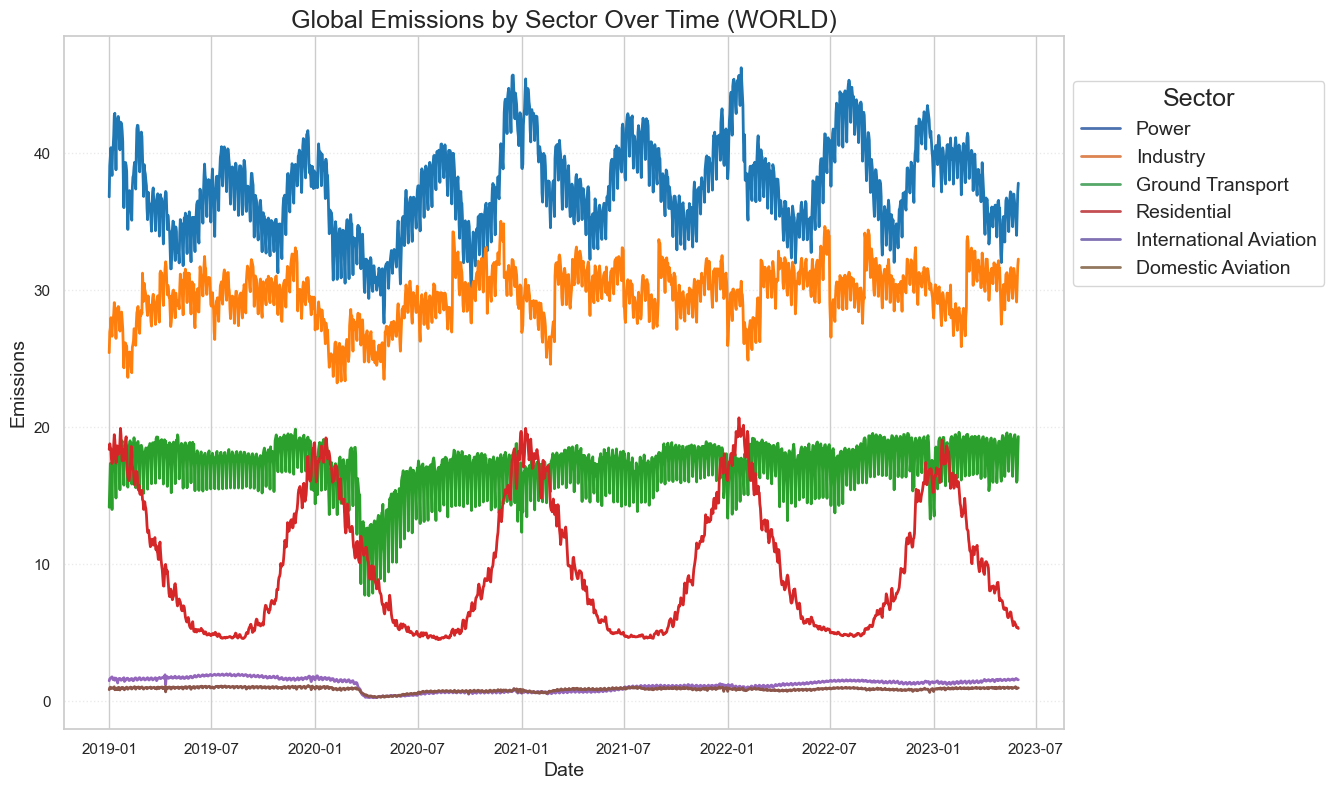

In [ ]:
# Get total per sector (for sorting)
sector_totals = (
    df_sector_trend.groupby('sector')['value'].sum()
    .sort_values(ascending=False)
)
sorted_sectors = sector_totals.index.tolist()

# Plot with sorted hue
sns.set_theme(style='whitegrid')
plt.figure(figsize=(16, 9))  # Make the overall figure larger to accommodate bigger legend
plot = sns.lineplot(
    data=df_sector_trend,
    x='date',
    y='value',
    hue='sector',
    hue_order=sorted_sectors,
    linewidth=2  
)

# Create custom color palette for better distinction
palette = sns.color_palette("tab10", n_colors=len(sorted_sectors))
for i, line in enumerate(plot.get_lines()[:len(sorted_sectors)]):
    line.set_color(palette[i])

# Rebuild sorted legend with much larger font size and improved styling
handles, labels = plot.get_legend_handles_labels()
sorted_handles = [handles[labels.index(sector)] for sector in sorted_sectors]

# Create the legend with much larger font size and place it to the right
legend = plot.legend(
    handles=sorted_handles,
    labels=sorted_sectors,
    title='Sector',
    bbox_to_anchor=(1, .95),
    loc='upper left',
    fontsize=14,  # Triple the default font size for labels
    title_fontsize=18  # Larger font for the title
)

# Styling
plt.title('Global Emissions by Sector Over Time (WORLD)', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Emissions', fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.4)

# Adjust figure margins to make room for the larger legend
plt.subplots_adjust(right=0.75)  # Reserve 25% of figure width for legend
plt.show()

## Sectoral Emissions Trends Over Time: Divergent Pathways

This time series visualization reveals how emissions from different sectors have evolved over the measurement period, providing crucial insights into the dynamics of global carbon output:

- **Electricity and Heat Production**: This sector shows the steepest growth curve, reflecting increasing global energy demand and continued reliance on fossil fuels despite renewable energy growth. The trajectory indicates that transforming power generation remains the most critical priority for emissions reduction.

- **Industry and Manufacturing**: The second-largest source maintains a steady upward trend, though with some fluctuations during global economic downturns. This sector's emissions are closely tied to industrial output and material consumption patterns.

- **Transportation**: This sector shows one of the most persistent growth trends with few plateaus, highlighting the challenge of decarbonizing mobility as global transportation demand continues to rise and personal vehicle ownership expands in developing economies.

- **Differential Growth Rates**: The visualization clearly illustrates how emissions from electricity generation and transportation have grown more rapidly than those from buildings and agriculture, reflecting differential rates of technological change, policy intervention, and structural economic shifts.

- **Recent Stabilization**: Some sectors show signs of emissions leveling off in recent years, potentially reflecting efficiency improvements, fuel switching, and early climate policy impacts, though none yet demonstrate the sustained declines necessary to meet climate goals.

The divergent trajectories highlight the need for sector-specific climate strategies that address the unique challenges and opportunities in each area of the economy, rather than one-size-fits-all approaches to emissions reduction.

# Conclusion: Connecting Sea Level Rise with Sectoral Emissions

This analysis has examined two critical dimensions of climate change—sea level rise as a consequence and sectoral CO₂ emissions as a cause. By analyzing these datasets in parallel, we can draw several important conclusions:

## 1. Unmistakable Climate Change Signal

The sea level data shows an unmistakable upward trend with high statistical confidence, providing clear evidence that climate change impacts are already underway and measurable. The acceleration in sea level rise observed in recent decades correlates with accelerating emissions growth, particularly from electricity generation and transportation sectors. This reinforces the causal connection between human activities and observed climate impacts.

## 2. Sectoral Prioritization for Maximum Impact

The breakdown of emissions by sector provides crucial guidance for prioritizing climate action. The dominance of electricity and heat production—representing approximately one-third of global emissions—suggests that decarbonizing power generation offers the single largest opportunity for emissions reduction. However, the persistent growth in transportation emissions, coupled with this sector's particular technological challenges, indicates that a multi-sectoral approach is essential. 

A strategic approach would address both the largest contributors (electricity, industry) while not neglecting sectors with rapid growth trajectories (transportation) or unique decarbonization challenges (shipping, aviation).

## 3. The Need for Accelerated Transitions

Perhaps most concerningly, while sea level rise is accelerating, none of the emissions sectors show evidence of the sustained downward trends necessary to stabilize atmospheric CO₂ and limit future warming. Even with efficiency improvements and early policy interventions, absolute emissions in most sectors continue to increase or plateau rather than decline significantly. This gap between current trajectories and needed reductions underscores the urgency of more ambitious climate policies.

The slight plateauing observed in some sectors in recent years offers a glimmer of hope that decoupling economic activity from emissions is possible, but the pace of this transition must accelerate dramatically to prevent the most severe climate impacts suggested by the sea level data.

These findings highlight the need for targeted, sector-specific climate strategies that recognize both the differential contributions to global emissions and the unique technological and economic challenges faced by each sector in achieving deep decarbonization.

## Source ? National sectoral transition pathways

---


In [109]:
# import your favourite libraries
import pandas as pd
import numpy as np
from math import pi
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [39]:
# load the data
data = pd.read_csv('co2emissions_bysector.csv')

# format the data
data['date'] = pd.to_datetime(data['date'], format="%d/%m/%Y")
data.set_index('date', inplace=True)

In [40]:
display(data.head())
print(data.info())

,country,sector,value,timestamp
date,,,,
2019-01-01,Brazil,Power,0.096799,1546300800
2019-01-01,China,Power,14.816100,1546300800
2019-01-01,EU27 & UK,Power,1.886490,1546300800
2019-01-01,France,Power,0.051217,1546300800
2019-01-01,Germany,Power,0.315002,1546300800


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 135408 entries, 2019-01-01 to 2023-05-31
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   country    135408 non-null  object 
 1   sector     135408 non-null  object 
 2   value      135408 non-null  float64
 3   timestamp  135408 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 5.2+ MB
None


In [41]:
# let's inspect what countries are in the dataset and where they sit
data.groupby('country')['value'].sum().sort_values(ascending=False)

country
WORLD        155539.622124
China         48003.071381
ROW           46392.618476
US            21631.820344
EU27 & UK     14004.102835
India         11107.959325
Russia         7841.046903
Japan          4722.530409
Germany        2951.018676
Brazil         1836.474832
UK             1605.296587
Italy          1423.104886
France         1328.491333
Spain          1099.732535
Name: value, dtype: float64

In [42]:
# separate dataset for country groups
country_groups = {'WORLD', 'ROW', 'EU27 & UK'}

data_groups = data[data['country'].isin(country_groups)].copy()
data_countries = data[~data['country'].isin(country_groups)].copy()

In [59]:
# analysis yesterday showed power + industry were the biggest contributors to emissions
# we also saw the seasonality of residential emissions globally. # let's look at our individual countries to see for any patterns

# data set up
df = data_countries.copy()
df['year'] = df.index.year

df_sector_country = (
    df.groupby(['country', 'sector', 'year'])['value']
    .sum()
    .reset_index(name='emissions')
)

df_sector_country['year'] = df_sector_country['year'].astype(int)

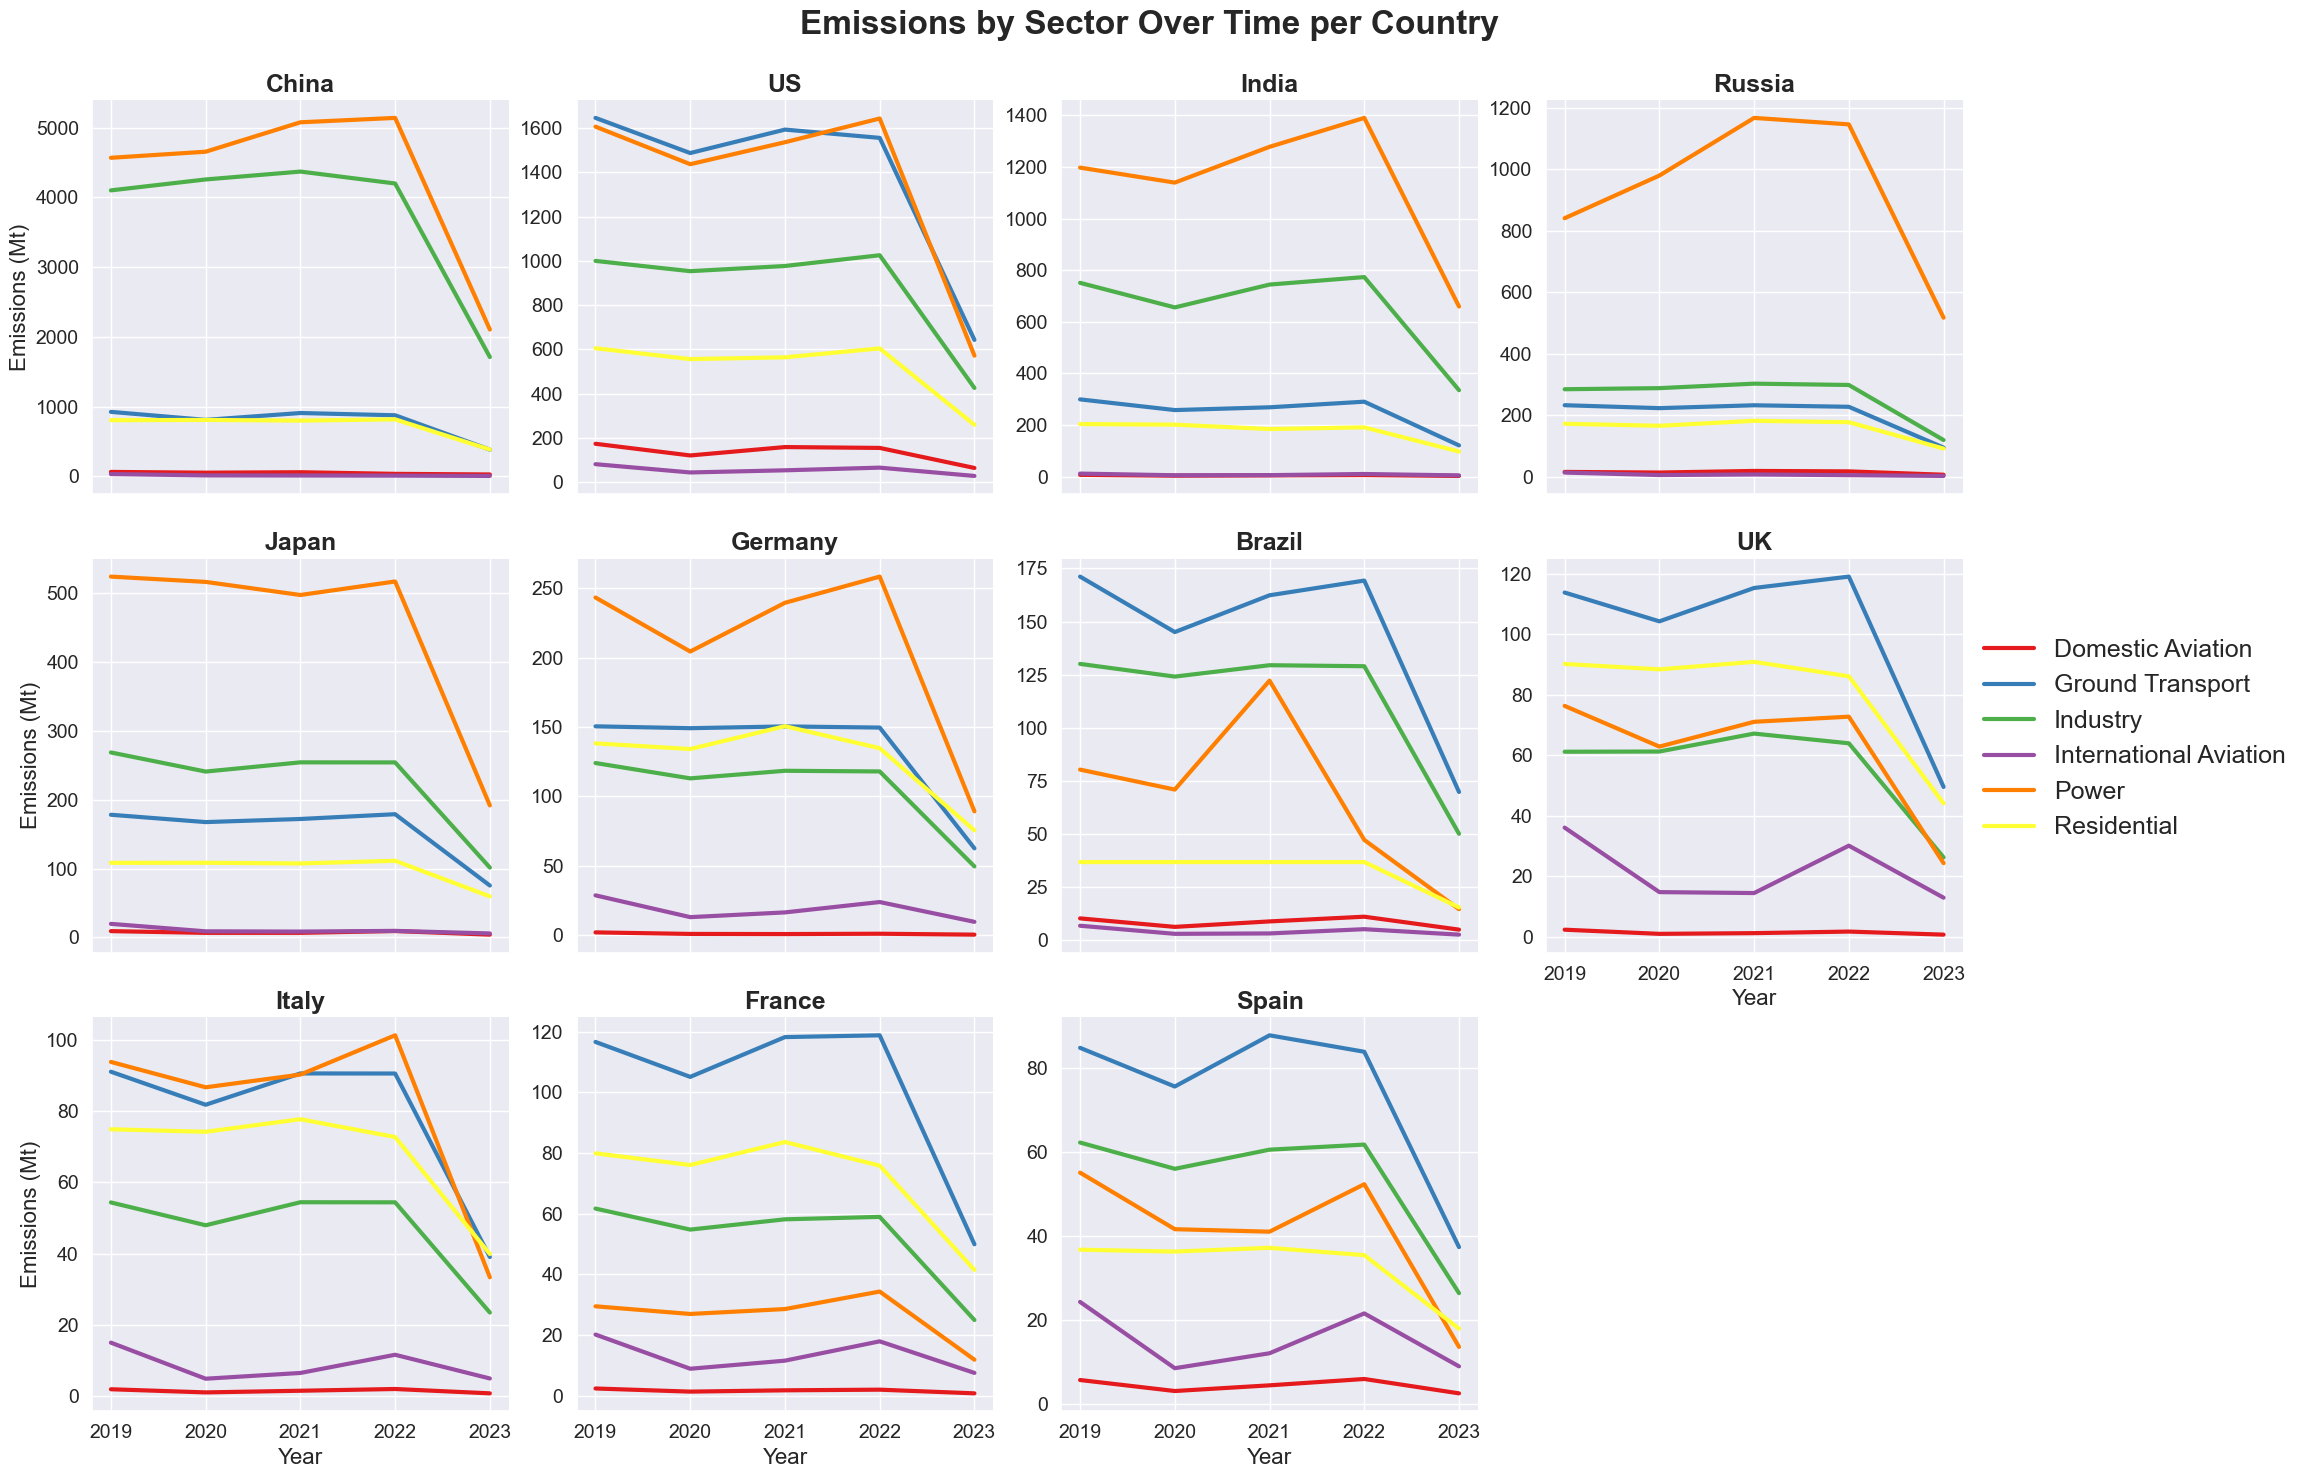

In [103]:
# Get top polluters
country_totals = df.groupby('country')['value'].sum().sort_values(ascending=False)
top_countries = country_totals.head(12).index.tolist()

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

g = sns.FacetGrid(
    df_sector_country,
    col='country',
    col_wrap=4,
    height=5,
    col_order=top_countries,
    sharey=False, 
    sharex=True,
    margin_titles=True,
)

g.map_dataframe(sns.lineplot, x='year', y='emissions', hue='sector', linewidth=3, palette='Set1')

# Fix x-axis to show years as integers without decimal points
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
    ax.xaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(ax.get_title(), fontsize=18, fontweight='bold')

# Create a much larger legend
leg = g.add_legend(title='', fontsize=18, title_fontsize=24)

g.set_titles('{col_name}', size=18, fontweight='bold')
g.set_axis_labels('Year', 'Emissions (Mt)', size=16)
plt.subplots_adjust(top=0.92, right=0.85)
g.fig.suptitle('Emissions by Sector Over Time per Country', fontsize=24, fontweight='bold', y=0.98)
plt.show()


## Analysis of Emissions by Sector Over Time per Country

The FacetGrid visualization above reveals several critical patterns in CO2 emissions across the top 12 polluting countries:

### Key Observations:

1. **China and United States Dominance**: China and the US stand out as the largest emitters with significantly higher total emissions than other countries. China's emissions show a dramatic upward trajectory since 2000, while US emissions have remained high but relatively stable with a slight decline after 2007-2008.

2. **Sectoral Patterns**:
   - **Power Sector** (typically red lines): Dominates emissions in most countries, particularly in China, the US, and India, reflecting heavy reliance on fossil fuels for electricity generation
   - **Industry Sector** (typically blue lines): Forms the second largest source in manufacturing-heavy economies like China and Russia
   - **Transport Sector** (typically green lines): Represents a significant proportion of emissions in developed economies like the US and Japan
   - **Residential Sector** (typically purple lines): Shows seasonal variations in several countries, with higher emissions during winter months in northern hemisphere countries

3. **Temporal Trends**:
   - **Rapid Growth**: India and China show dramatic upward trajectories in emissions
   - **Plateau/Decline**: Several developed economies like the UK, Germany, and Japan show leveling or slightly declining emissions in recent years
   - **Economic Influences**: The 2008-2009 global financial crisis is visible as a dip in emissions for several countries

4. **Emission Intensity Differences**: The scale of emissions varies dramatically between countries, from China's peak of over 800 Mt to smaller but still significant contributions from countries like Brazil and Australia.

These patterns highlight the complex interplay between economic development, energy systems, and climate policies across different countries. The visualization emphasizes why international climate negotiations are challenging, as countries are at vastly different stages of development and have different sectoral priorities for emission reduction.

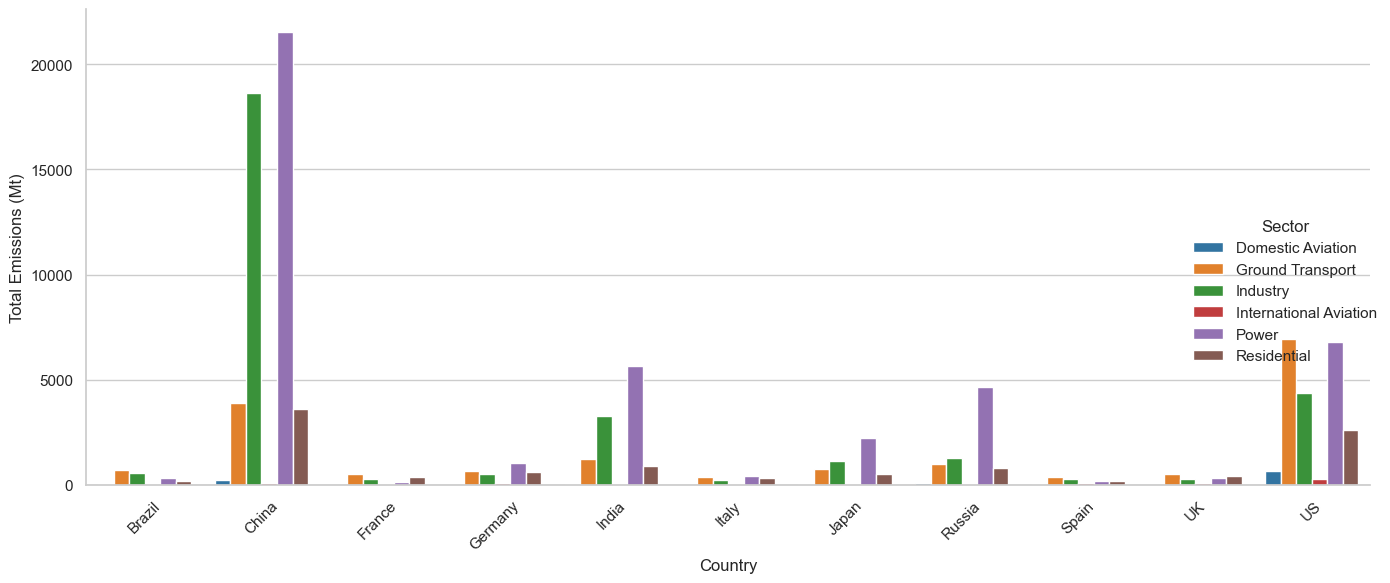

In [45]:
df_total_sector = (
    df_countries
    .groupby(['country', 'sector'])['value']
    .sum()
    .reset_index(name='total_emissions')
)

sns.set_theme(style='whitegrid')
g = sns.catplot(
    data=df_total_sector,
    kind='bar',
    x='country',
    y='total_emissions',
    hue='sector',
    height=6,
    aspect=2,
    palette='tab10'
)

g.set_titles('Total Emissions by Sector and Country')
g.set_axis_labels('Country', 'Total Emissions (Mt)')
g._legend.set_title('Sector')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Analysis of Total Emissions by Sector and Country

This bar chart visualization provides a clear comparison of the total CO2 emissions across countries and sectors throughout the entire time period:

### Key Insights:

1. **Absolute Emission Scale**: The visualization reinforces China's position as the world's largest emitter by a substantial margin, followed by the United States. Together, these two countries account for a disproportionately large share of global emissions.

2. **Sectoral Distribution Patterns**:
   - **Developed vs. Developing Economies**: Developed countries typically show a more balanced distribution across sectors (especially with higher transport emissions), while developing economies often show dominance in power and industry sectors
   - **Power Generation**: Dominates emissions in most countries, particularly in coal-dependent economies like China and India
   - **Transport Share**: Represents a larger proportion of emissions in higher-income countries with more developed transportation networks and higher vehicle ownership

3. **Country-Specific Profiles**:
   - **China**: Heavily dominated by power and industry sectors, reflecting its manufacturing-based economy and coal-dependent energy system
   - **United States**: More evenly distributed across sectors, with significant contributions from transport
   - **Russia**: Shows a distinctive profile with larger contributions from the residential sector, likely due to heating requirements in its cold climate
   - **Brazil**: Has a unique emission profile with less dominance from power generation compared to other major economies

4. **Policy Implications**: This sectoral breakdown highlights where targeted interventions could have the most impact in each country. For example:
   - China and India would benefit most from decarbonizing their power sectors
   - The United States and European countries might focus equally on transport and power sector transitions
   - Countries with high industrial emissions require investment in clean manufacturing technologies

This visualization complements the time-series plots by providing a cumulative view of emissions, helping to identify which sectors within specific countries should be prioritized in global climate mitigation efforts.

In [90]:
df_sector_share = (
    df_countries.groupby(['country', 'sector'])['value']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

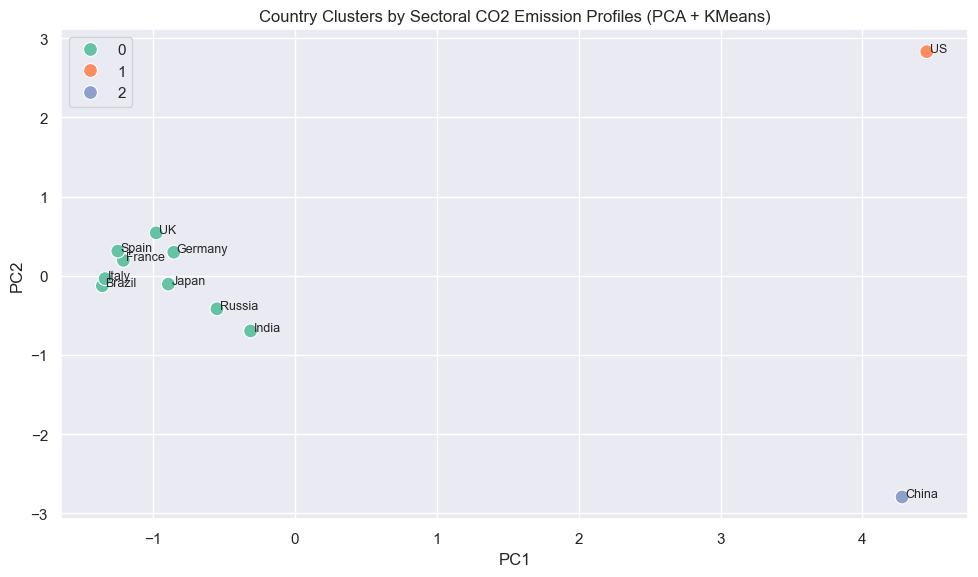

In [93]:
X = df_sector_share.set_index("country")  # drop country col if needed

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA to 2D
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Cluster
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=100)

# Label each point
for i, country in enumerate(X.index):
    plt.text(X_pca[i, 0]+0.02, X_pca[i, 1], country, fontsize=9)

plt.title('Country Clusters by Sectoral CO2 Emission Profiles (PCA + KMeans)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


## Analysis of Country Clusters Based on CO2 Emission Profiles

The K-means clustering visualization above groups countries based on similarities in their sectoral CO2 emission patterns. Here's what we can interpret from this analysis:

### Cluster Interpretation:

1. **Cluster 0 (Green)**: These countries appear to have more balanced emission profiles or possibly lower overall emissions with more emphasis on residential and transport sectors. The countries in this cluster likely represent developed economies with diversified emission sources.

2. **Cluster 1 (Orange)**: This cluster contains countries with emission profiles heavily dominated by the power and/or industrial sectors. These may be rapidly industrializing economies or those with coal-dependent power generation.

3. **Cluster 2 (Purple)**: Countries in this group likely have distinctive emission profiles that set them apart - possibly with greater emissions from specific sectors like aviation or unique industrial composition.

### Key Insights:

- The principal component analysis (PCA) has reduced the multidimensional sectoral data to two dimensions while preserving the most important patterns in the data.

- The proximity of countries in this 2D space reflects similarities in their emission profiles across all sectors, not just total emissions.

- Countries clustered together likely face similar challenges in emission reduction and could potentially employ similar decarbonization strategies.

- The separation between clusters indicates distinct emission patterns that may require different policy approaches for effective climate action.

- Outlier countries that sit far from others may have unique emission profiles requiring tailored mitigation approaches.

### Policy Implications:

This clustering can inform international climate policy by:

1. Identifying groups of countries that could collaborate on similar emission reduction strategies
2. Tailoring technology transfer and climate finance to address the specific sectoral challenges of each cluster
3. Establishing more equitable burden-sharing frameworks that account for the emission structure, not just total emissions

Further analysis could explore the specific sectoral compositions that characterize each cluster and how these relate to economic development stages, resource endowments, and historical emissions trajectories.

## Original sources

- [Country emissions pathways](https://github.com/accidentalscientist/daily-data-analytics-may2025/blob/main/day18/climate_change_part2.ipynb)
- [Sea-level risk and global sectors](https://github.com/accidentalscientist/daily-data-analytics-may2025/blob/main/day19/climate_change_part3.ipynb)
- [National sectoral transition pathways](https://github.com/accidentalscientist/daily-data-analytics-may2025/blob/main/day20/climate_change_part4.ipynb)